# EEG Emotion Art Generator - Inference Only

Questo notebook illustra un flusso completo per l’analisi e la classificazione delle emozioni a partire da segnali EEG. In particolare, si parte dal caricamento di un modello di classificazione pre-addestrato, il cui training è stato effettuato in un notebook separato denominato `EEG Emotion Classifier`, specifico per segnali EEG. Successivamente, viene caricato e preprocessato un singolo campione EEG estratto da un file CSV, che viene scalato e preparato per l’inferenza. Il modello viene quindi utilizzato per prevedere le probabilità delle classi emotive (negative, neutrali, positive), e l’emozione dominante viene individuata.

Per migliorare l’accuratezza e la robustezza della classificazione, viene applicata una logica fuzzy che raffina la stima dell’emozione dominante, fornendo anche un valore di intensità fuzzy. A seguire, il notebook genera un’immagine astratta rappresentativa dello stato emotivo rilevato, utile per una visualizzazione creativa del risultato. Infine, viene mostrata l’importanza delle feature EEG usate dal modello nella classificazione, evidenziando quali segnali hanno avuto maggiore influenza nella predizione finale.

**File necessari per il funzionamneto:**

*   `eeg_sample.csv`(il segnale da classificare)
*   `emotion_classifier_model.keras` (il modello di rete neurale addestrato)
*   `scaler.pkl`(scaler usato in fase di addestramento)
*   `support_function.py`(funzioni di supporto richiamate)

## 0: Setup Iniziale e Importazione Librerie


In [41]:
# Installazione delle librerie
!pip install -q pandas numpy scikit-learn tensorflow Pillow scikit-fuzzy matplotlib seaborn

print("\nLibrerie installate con successo!")


Librerie installate con successo!


In [42]:
# Accesso a Google Drive
from google.colab import drive
import sys

# Analisi e manipolazione dei dati
import pandas as pd
import numpy as np
import os

# Visualizzazione dei dati
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing e modellazione con Scikit-learn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
import joblib

# Costruzione, addestramento e salvataggio di modelli con TensorFlow / Keras
import tensorflow as tf
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.utils import to_categorical

# Logica fuzzy con SciKit-Fuzzy
import skfuzzy as fuzz
from skfuzzy import control as ctrl

# Manipolazione di immagini
from PIL import Image, ImageDraw
from IPython.display import display

# Operazioni casuali
import random

# Rimozione warning
import warnings
warnings.filterwarnings('ignore', category=UserWarning, module='tensorflow')

## 1: Collegamento a Google Drive e Importazione File Necessari


In [43]:
# Monta Google Drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [44]:
# --- Percorso base del progetto su Google Drive ---
base_path = "/content/drive/MyDrive/Colab Notebooks/IA FROM ENGINEERING TO ARTS/INFERENZA"

# --- Sottocartelle ---
support_path = os.path.join(base_path, "FILE DI SUPPORTO")
sample_path = os.path.join(base_path, "EEG SAMPLE")

# --- Aggiunta support_path al sys.path se non già presente ---
if support_path not in sys.path:
    sys.path.append(support_path)

# --- Import del modulo di supporto ---
import support_function

# --- File paths ---
input_eeg_file = os.path.join(sample_path, "pos_inc.csv")
config_modello = os.path.join(support_path, "emotion_classifier_model.keras")
scaler_path = os.path.join(support_path, "scaler.pkl")

print(f"Importazione avvenuta con Successo.")

Importazione avvenuta con Successo.


## 2: Inizializzazione e Setup dell'Ambiente


In [45]:
# Numero di classi emotive
num_classes = 3  # NEGATIVE, NEUTRAL, POSITIVE

# Caricamento struttura dati EEG (colonne)
if os.path.exists(input_eeg_file):
    single_eeg_df = pd.read_csv(input_eeg_file)
    eeg_cols = single_eeg_df.columns.tolist()
    print(f"Nomi colonne EEG caricati da {os.path.basename(input_eeg_file)}.")
else:
    eeg_cols = [f'feature_{i}' for i in range(2548)]
    print("File EEG non trovato. Nomi colonne EEG impostati come placeholder.")

# Inizializzazione del LabelEncoder
label_encoder = LabelEncoder()
label_encoder.fit(["NEGATIVE", "NEUTRAL", "POSITIVE"]);

print(f"\nNumero di colonne EEG: {len(eeg_cols)}")
print(f"\nNumero di classi emotive: {num_classes}")
print(f"\nClassi emotive codificate: {label_encoder.classes_}")

Nomi colonne EEG caricati da pos_inc.csv.

Numero di colonne EEG: 2548

Numero di classi emotive: 3

Classi emotive codificate: ['NEGATIVE' 'NEUTRAL' 'POSITIVE']


## 3: Flusso di Inferenza per un Singolo Campione EEG


### Configurazione del Segnale EEG e Pre-Elaborazione dei dati
Estrazione di un singolo campione EEG, seguito dal caricamento dello scaler pre-addestrato e applicazione dello scaling per normalizzare i dati in ingresso al modello.

In [46]:
# Caricamento del Campione
my_single_eeg_sample_raw = single_eeg_df.iloc[0].values
print(f"\nCampione EEG caricato da {os.path.basename(input_eeg_file)}.")


# Caricamento dello Scaler e Scaling del Campione
scaler = joblib.load(scaler_path)

new_eeg_scaled_sample = scaler.transform(my_single_eeg_sample_raw.reshape(1, -1))
print("\nSegnale EEG scalato correttamente.")

print(f"\nForma del campione EEG originale: {my_single_eeg_sample_raw.shape}")
print(f"\nForma del campione EEG scalato: {new_eeg_scaled_sample.shape}")


Campione EEG caricato da pos_inc.csv.

Segnale EEG scalato correttamente.

Forma del campione EEG originale: (2548,)

Forma del campione EEG scalato: (1, 2548)


### Classificazione del Segnale (Rete Neurale)
Caricamento del modello neurale pre-addestrato e predizione delle probabilità delle classi emotive per il campione scalato. Identificazione e stampa dell’emozione dominante.


Modello emotion_classifier_model.keras caricato con successo.



1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 366ms/step

Probabilità emozioni:

  → NEGATIVE: 0.1288
  → NEUTRAL: 0.0118
  → POSITIVE: 0.8594

Emozione dominante predetta: POSITIVE



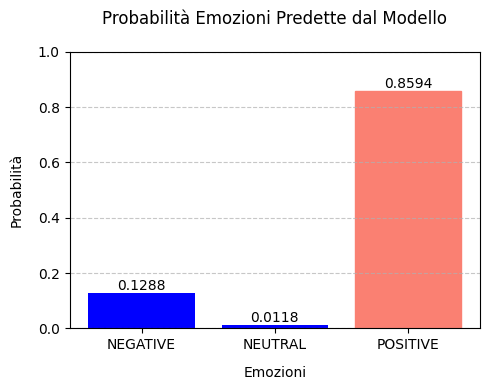

In [47]:
# Caricamento del modello
model = load_model(config_modello)
print("\nModello emotion_classifier_model.keras caricato con successo.\n")

# Classificazione
emotion_probabilities = model.predict(new_eeg_scaled_sample)[0]
predicted_class_idx = np.argmax(emotion_probabilities)
predicted_emotion_label = label_encoder.inverse_transform([predicted_class_idx])[0]

# Stampa formattata delle probabilità emotive (con 4 cifre decimali)
print("\nProbabilità emozioni:\n")
for emotion, prob in zip(label_encoder.classes_, emotion_probabilities):
    print(f"  → {emotion}: {prob:.4f}")

print(f"\nEmozione dominante predetta: {predicted_emotion_label}\n")


# Creazione del grafico a barre
plt.figure(figsize=(5, 4))
bars = plt.bar(label_encoder.classes_, emotion_probabilities, color='blue')

# Evidenziazione della barra con probabilità più alta
bars[predicted_class_idx].set_color('salmon')

# Aggiunta dei valori sulle barre
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{height:.4f}',
             ha='center', va='bottom')

plt.title('Probabilità Emozioni Predette dal Modello', pad=20)
plt.xlabel('Emozioni', labelpad=10)    # Allontana etichetta asse x
plt.ylabel('Probabilità', labelpad=10) # Allontana etichetta asse y
plt.ylim(0, 1)  # Imposta il limite dell'asse y tra 0 e 1
plt.xticks(rotation=0)  # Etichette dritte
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()  # Migliora il layout per evitare sovrapposizioni
plt.show()



### Implementazione della Logica Fuzzy (Raffinamento dell’emozione)
Utilizzo di una funzione fuzzy per interpretare le probabilità predette, restituendo un’etichetta di emozione dominante più sfumata e un valore di intensità fuzzy.




Emozione dominante raffinata (fuzzy logic):

   → Etichetta: POSITIVE
   → Intensità fuzzy: 0.82

   → Intensità dettagliate: NEGATIVE: 0.17546, NEUTRAL: 0.16676, POSITIVE: 0.82305





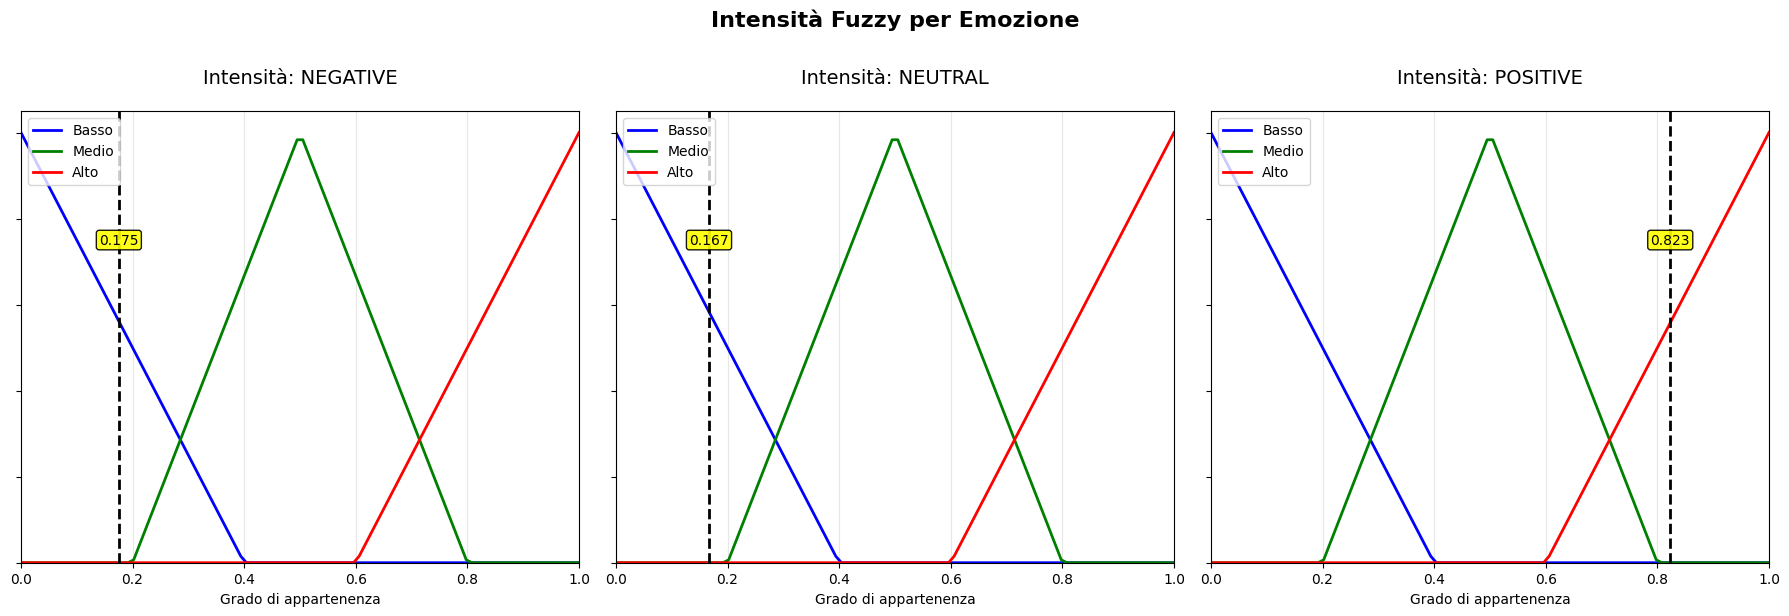

In [48]:
# Calcolo dell'emozione dominante con logica fuzzy
dominant_emotion_fuzzy, fuzzy_intensity, all_intensities = support_function.get_fuzzy_emotion_intensity(emotion_probabilities, list(label_encoder.classes_))


#  Output risultato fuzzy
if dominant_emotion_fuzzy is not None:
    print("\nEmozione dominante raffinata (fuzzy logic):")
    print(f"\n   → Etichetta: {dominant_emotion_fuzzy}")
    print(f"   → Intensità fuzzy: {fuzzy_intensity:.2f}")
    print("\n   → Intensità dettagliate: " + ", ".join(f"{emo}: {all_intensities[emo]:.5f}" for emo in ['NEGATIVE', 'NEUTRAL', 'POSITIVE']))
else:
    print("\nErrore nella logica fuzzy: impossibile determinare l'emozione.")
print("\n\n")

# Definizione dominio x e funzioni di membership
x = np.linspace(0, 1, 100)
basso = fuzz.trimf(x, [0, 0, 0.4])
medio = fuzz.trimf(x, [0.2, 0.5, 0.8])
alto  = fuzz.trimf(x, [0.6, 1, 1])

def calc_memberships(value):
    mu_basso = fuzz.interp_membership(x, basso, value)
    mu_medio = fuzz.interp_membership(x, medio, value)
    mu_alto  = fuzz.interp_membership(x, alto, value)
    return mu_basso, mu_medio, mu_alto

# Creo figura con 1 riga e 3 colonne
fig, axs = plt.subplots(1, 3, figsize=(18, 6))
emotion_list = ['NEGATIVE', 'NEUTRAL', 'POSITIVE']

for i, emo in enumerate(emotion_list):
    intens_value = all_intensities[emo]
    mu_b, mu_m, mu_a = calc_memberships(intens_value)
    ax = axs[i]

    # Plot funzioni di membership
    ax.plot(x, basso, 'b-', linewidth=2, label='Basso')
    ax.plot(x, medio, 'g-', linewidth=2, label='Medio')
    ax.plot(x, alto,  'r-', linewidth=2, label='Alto')

    # Linea verticale per valore intensità
    ax.axvline(intens_value, color='black', linestyle='--', linewidth=2)

    # Aggiunta riquadro giallo con il valore a metà altezza
    ax.text(intens_value, 0.75, f'{intens_value:.3f}',
            ha='center', va='center',
            bbox=dict(facecolor='yellow', alpha=0.9, edgecolor='black', boxstyle='round,pad=0.2'),
            fontsize=10)

    # Impostazione assi x con ticks da 0 a 1 con passo 0.2
    ax.set_xticks(np.arange(0, 1.1, 0.2))
    ax.set_xticklabels([f"{tick:.1f}" for tick in np.arange(0, 1.1, 0.2)], fontsize=10)
    ax.set_xlabel('Grado di appartenenza', fontsize=10)

    ax.set_ylabel('')
    ax.set_yticklabels([])

    # Etichette e formattazione
    ax.set_title(f'Intensità: {emo}', fontsize=14, pad=20)

    # Limiti assi
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1.05)

    # Griglia verticale (solo linee verticali)
    ax.grid(True, axis='x', alpha=0.3)

    # Legenda
    ax.legend(loc='upper left', fontsize=10)

plt.tight_layout()
plt.suptitle('Intensità Fuzzy per Emozione', fontsize=16, y=1.02, fontweight='bold')
plt.subplots_adjust(top=0.85)  # Aumenta lo spazio sopra i subplots
plt.show()

### Generazione dell'Immagine Astratta in base all'emozione
Generazione e salvataggio di un’immagine di arte astratta parametrizzata sull’emozione dominante fuzzy e relativa intensità,


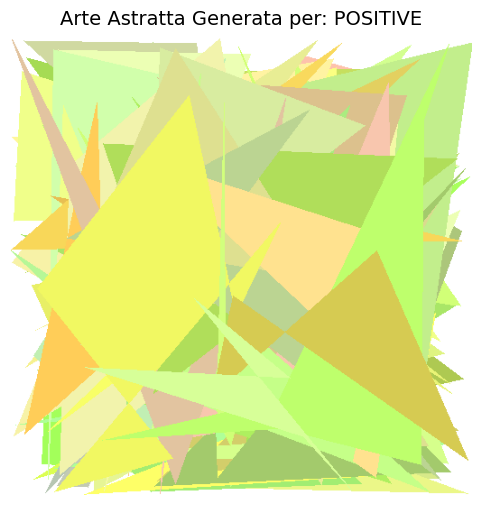


Arte astratta generata e salvata come 'abstract_art_POSITIVE.png'.




In [49]:
if dominant_emotion_fuzzy is not None:

    # Generazione immagine passando tutte le intensità fuzzy
    art_image = support_function.generate_abstract_art(dominant_emotion_fuzzy, all_intensities)

    # Costruzione del nome del file
    art_path = f'abstract_art_{dominant_emotion_fuzzy.replace(" ", "_")}.png'

    # Salvataggio immagine
    art_image.save(art_path)

    # Visualizzazione immagine con titolo sopra
    plt.figure(figsize=(6,6))
    plt.title(f'Arte Astratta Generata per: {dominant_emotion_fuzzy}', fontsize=14)
    plt.axis('off')
    img = Image.open(art_path)
    plt.imshow(img)
    plt.show()

    print(f"\nArte astratta generata e salvata come '{art_path}'.\n\n")

else:
    print("\nImpossibile generare arte astratta: emozione fuzzy non valida.")



### Saliency Map basata sui Gradienti
Tecnica di interpretabilità che misura l’importanza di ciascuna feature di input calcolando il gradiente dell’output (per una classe specifica) rispetto all’input stesso.

**Nota:** L'implementazione standard di Grad-CAM è più efficace e intuitiva per i modelli CNN che elaborano dati spaziali (come le immagini). Per i dati EEG, che sono sequenziali o multicanale, è preferibile applicare altre tecniche.


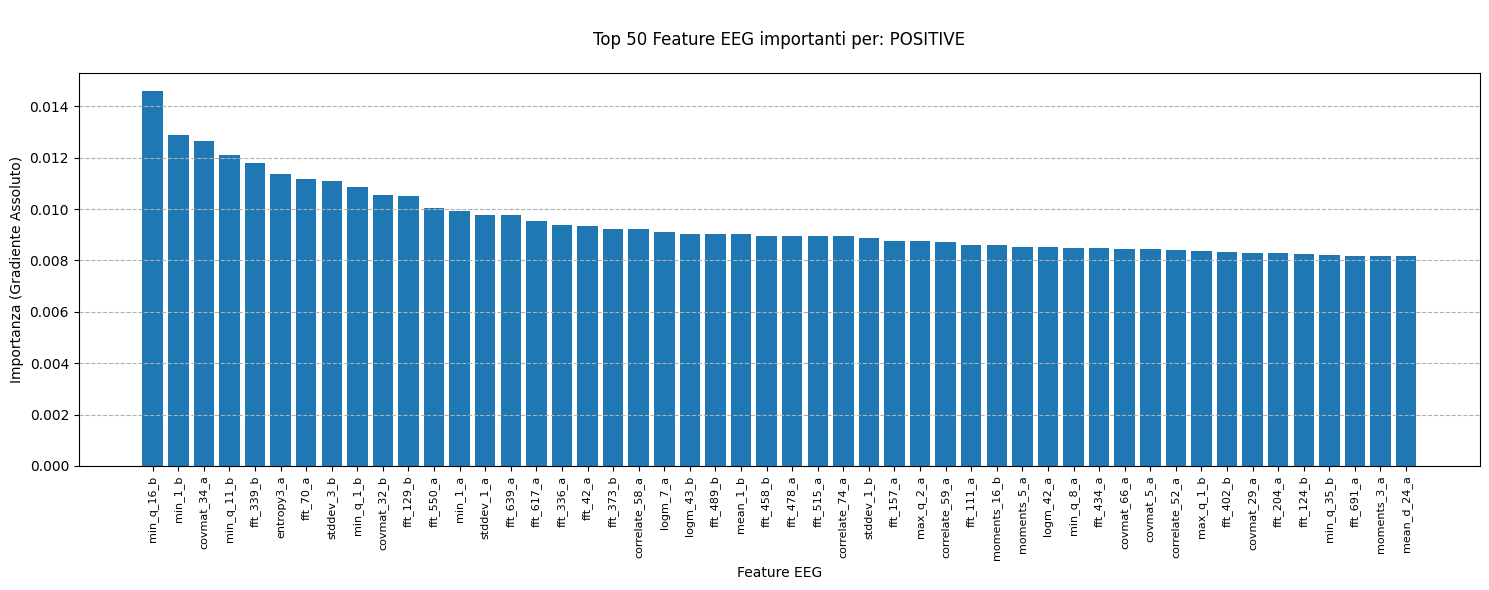


Feature più importante per la predizione: 'min_q_16_b'


Grafico importanza feature salvato come 'feature_importance_POSITIVE.png'.


In [50]:
# Feature Importance
if dominant_emotion_fuzzy is not None:

    # Calcolo dell'importanza delle feature EEG rispetto alla classe predetta (gradiente)
    importance_map = support_function.compute_feature_importance_ffnn(
        model, new_eeg_scaled_sample[0], predicted_class_idx
    )

    plt.figure(figsize=(15, 6))

    # Se le feature EEG sono > 50, visualizza solo le 50 più rilevanti
    if len(eeg_cols) > 50:
        sorted_idx = np.argsort(importance_map)[::-1][:50]  # Indici top 50 feature per importanza
        cols_display = [eeg_cols[i] for i in sorted_idx]    # Nomi delle feature selezionate
        imp_display = importance_map[sorted_idx]            # Valori di importanza corrispondenti
        plt.bar(cols_display, imp_display)
        plt.xticks(rotation=90, fontsize=8)
        plt.title(f'\nTop 50 Feature EEG importanti per: {predicted_emotion_label}', pad=20)
    else:
        # Se il numero di feature è ≤ 50, visualizza tutte
        plt.bar(eeg_cols, importance_map)
        plt.xticks(rotation=90, fontsize=10)
        plt.title(f'Importanza Feature EEG per: {predicted_emotion_label}', pad=20)

    # Etichette e layout grafico
    plt.xlabel('Feature EEG')
    plt.ylabel('Importanza (Gradiente Assoluto)')
    plt.grid(axis='y', linestyle='--')
    plt.tight_layout()

    # Salvataggio del grafico in un file PNG
    importance_path = f'feature_importance_{predicted_emotion_label.replace(" ", "_")}.png'
    plt.savefig(importance_path)
    plt.show()


    # Stampa della feature più importante per la predizione
    max_importance_idx = np.argmax(importance_map)
    print(f"\nFeature più importante per la predizione: '{eeg_cols[max_importance_idx]}'\n\n")


    print(f"Grafico importanza feature salvato come '{importance_path}'.")
